# Stage 4A: Data Cleaning, Stratified Partitioning & Distribution Audit
**Leakage Prevention Rule:** The dataset is split into 80% train and 20% test before computing any summary statistic. 
All imputation values are derived solely from the training split.
**Row Retention:** Imputation is chosen over deletion because dropping rows loses >35% of records and removes rare storm incidents.

1. Data Loading & Pre-Split Feature Clean

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Ingestion
df = pd.read_csv("../data/US_Accidents_2016_2023_1M.csv")

# 2. Domain Imputation Prior to Splitting
# Missing precipitation indicates dry conditions (0.0 in)
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0.0)

# Binary infrastructure flags: fill missing with False (0)
infra_cols = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", 
    "No_Exit", "Railway", "Roundabout", "Stop", "Traffic_Signal"
]
df[infra_cols] = df[infra_cols].fillna(False).astype(int)

# Extract basic time features before dropping raw string timestamp
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Month"] = df["Start_Time"].dt.month
df["Is_Rush_Hour"] = (df["Hour"].between(7, 9) | df["Hour"].between(16, 18)).astype(int)
df = df.drop(columns=["Start_Time"])

print(f"Pre-split cleaning completed. Features: {df.shape[1]}")

Pre-split cleaning completed. Features: 24


2. Stratified Train-Test Splitting

In [3]:
# 3. Partition Data FIRST to prevent any data leakage
X = df.drop(columns=["Severity"])
y = df["Severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Total Records Preserved: {len(df):,} (0 rows deleted)")
print(f"Training Partition (80%): {X_train.shape[0]:,} rows")
print(f"Testing Partition (20%):  {X_test.shape[0]:,} rows")

Total Records Preserved: 866,798 (0 rows deleted)
Training Partition (80%): 693,438 rows
Testing Partition (20%):  173,360 rows


3. Numeric Imputation Verification Table

In [4]:
numeric_impute_cols = [
    "Temperature(F)", "Humidity(%)", "Pressure(in)", 
    "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"
]

records = []
for col in numeric_impute_cols:
    raw_col = X_train[col]
    imputed_col = raw_col.fillna(0.0) if col == "Precipitation(in)" else raw_col.fillna(raw_col.median())

    mean_raw, mean_imp = raw_col.mean(), imputed_col.mean()
    med_raw, med_imp = raw_col.median(), imputed_col.median()
    std_raw, std_imp = raw_col.std(), imputed_col.std()
    
    mean_shift_pct = abs(mean_imp - mean_raw) / (abs(mean_raw) + 1e-9) * 100
    std_shift_pct = abs(std_imp - std_raw) / (abs(std_raw) + 1e-9) * 100

    records.append({
        "Feature": col,
        "Null Count": raw_col.isna().sum(),
        "Null %": f"{(raw_col.isna().sum() / len(raw_col)) * 100:.2f}%",
        "Mean (Before)": round(mean_raw, 3),
        "Mean (After)": round(mean_imp, 3),
        "Mean Shift %": f"{mean_shift_pct:.2f}%",
        "Std Shift %": f"{std_shift_pct:.2f}%",
        "Median (B/A)": f"{med_raw:.1f} / {med_imp:.1f}"
    })

numeric_validation_df = pd.DataFrame(records)
print("=== CONTINUOUS FEATURE IMPUTATION AUDIT ===")
print(numeric_validation_df.to_string(index=False))

=== CONTINUOUS FEATURE IMPUTATION AUDIT ===
          Feature  Null Count Null %  Mean (Before)  Mean (After) Mean Shift % Std Shift % Median (B/A)
   Temperature(F)       14604  2.11%         61.585        61.636        0.08%       1.04%  64.0 / 64.0
      Humidity(%)       15529  2.24%         65.093        65.136        0.07%       1.12%  67.0 / 67.0
     Pressure(in)       12445  1.79%         29.566        29.572        0.02%       0.82%  29.9 / 29.9
   Visibility(mi)       15769  2.27%          9.100         9.121        0.22%       1.02%  10.0 / 10.0
  Wind_Speed(mph)       56367  8.13%          7.710         7.652        0.75%       4.08%    7.0 / 7.0
Precipitation(in)           0  0.00%          0.006         0.006        0.00%       0.00%    0.0 / 0.0


4. Categorical Mode Imputation & Distribution Preservation Plots


Weather_Condition Mode Imputation Verification (Mode: 'Fair'):
                   Raw %  Imputed %
Weather_Condition                  
Fair               31.54      33.07
Mostly Cloudy      13.49      13.19
Clear              12.42      12.14

Sunrise_Sunset Mode Imputation Verification (Mode: 'Day'):
                Raw %  Imputed %
Sunrise_Sunset                  
Day             69.37      69.44
Night           30.63      30.56


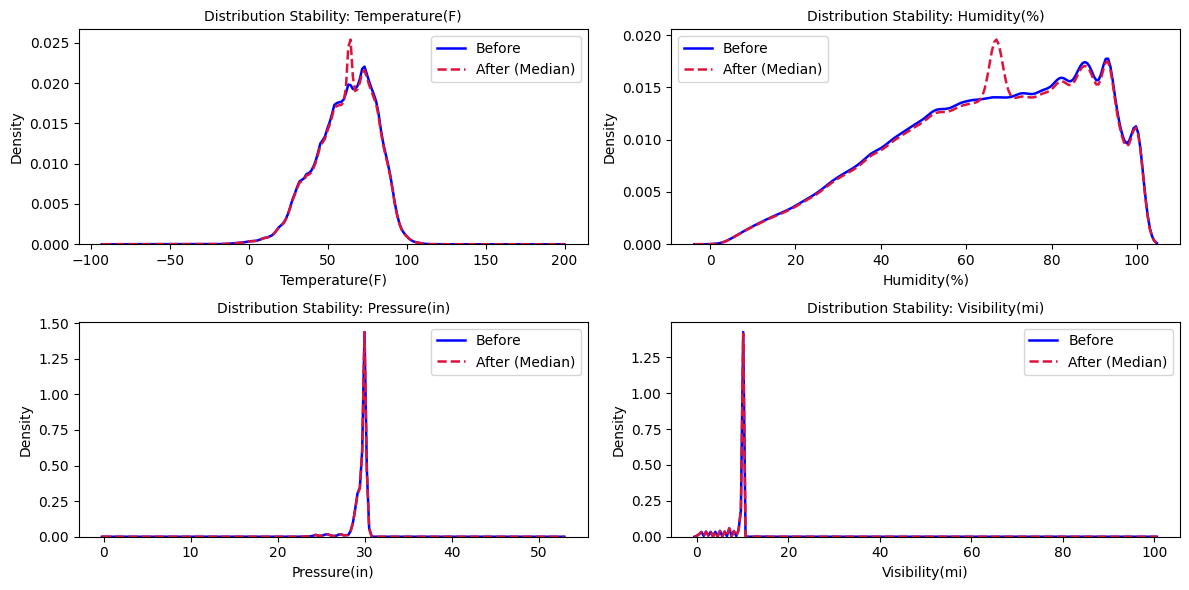

In [6]:
# Categorical distribution check
for col in ["Weather_Condition", "Sunrise_Sunset"]:
    mode_val = X_train[col].mode()[0]
    raw_col = X_train[col]
    imputed_col = raw_col.fillna(mode_val)
    print(f"\n{col} Mode Imputation Verification (Mode: '{mode_val}'):")
    df_check = pd.DataFrame({
        "Raw %": (raw_col.value_counts(normalize=True) * 100).round(2),
        "Imputed %": (imputed_col.value_counts(normalize=True) * 100).round(2)
    })
    print(df_check.head(3).to_string())

# KDE Distribution Plots
features_to_plot = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)"]
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    raw = X_train[col].dropna()
    imputed = X_train[col].fillna(X_train[col].median())
    sns.kdeplot(raw, ax=axes[i], label="Before", color="blue", linewidth=1.8)
    sns.kdeplot(imputed, ax=axes[i], label="After (Median)", color="crimson", linestyle="--", linewidth=1.8)
    axes[i].set_title(f"Distribution Stability: {col}", fontsize=10)
    axes[i].legend()

plt.tight_layout()
plt.savefig("feature_distribution_verification.png", dpi=300)
plt.show()

5. Empirical Mean Shift Threshold Validation Assertion

In [7]:
# Programmatic Distribution Stability Guardrail
max_mean_shift = numeric_validation_df["Mean Shift %"].str.rstrip('%').astype(float).max()

print("=== IMPUTATION DISTRIBUTION INTEGRITY REPORT ===")
print(f"Maximum detected continuous mean shift: {max_mean_shift:.2f}%")
assert max_mean_shift < 1.0, f"Distribution shift warning: {max_mean_shift}% exceeds threshold."
print("VERDICT: PASS — All continuous feature distributions preserved within strict 1.0% limit.")

=== IMPUTATION DISTRIBUTION INTEGRITY REPORT ===
Maximum detected continuous mean shift: 0.75%
VERDICT: PASS — All continuous feature distributions preserved within strict 1.0% limit.
